# Model 4 of 5 — GAN-Based Rare Cell Augmentation (DCGAN)
**Hematological AI Decision Support System — MSc Biotechnology, VIT**

**Goal:** Train a DCGAN per minority WBC class, generate synthetic images, and prove via before/after classifier comparison that GAN augmentation improves minority-class recognition.

**Pipeline stage:** Model 4 of 5. Reuses Model 1's PBC dataset and re-trains a classifier identical to Model 1's setup — this notebook is the direct evidence for your augmentation claim.

Run in Colab with a **GPU runtime** (Runtime → Change runtime type → T4 GPU). Expect ~1 hour total runtime (GAN training + two classifier trainings).

In [1]:
# 1. Environment setup
!pip install -q kagglehub torchmetrics

import os, random, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.0 MB/s eta 0:00:00
Device: cuda


In [2]:
# 2. Re-download PBC dataset (same source as Model 1, no key needed)
import kagglehub

path = kagglehub.dataset_download("unclesamulus/blood-cells-image-dataset")
DATA_ROOT = Path(path)

class_dirs = [d for d in DATA_ROOT.rglob('*') if d.is_dir() and any(f.suffix.lower() in ['.jpg','.jpeg','.png'] for f in d.glob('*'))]
print("Found class folders:")
for d in class_dirs:
    print(f"  {d.name}: {len(list(d.glob('*')))} images")

100%|██████████| 268M/268M [00:02<00:00, 96.7MB/s]

Extracting files...


Found class folders:
  platelet: 2348 images
  ig: 2895 images
  erythroblast: 1551 images
  eosinophil: 3117 images
  monocyte: 1420 images
  neutrophil: 3329 images
  lymphocyte: 1214 images
  basophil: 1218 images


In [3]:
# 3. Confirm classes + identify minority classes to augment
TARGET_CLASSES = ['neutrophil', 'lymphocyte', 'monocyte', 'eosinophil', 'basophil']

class_paths = {}
for d in class_dirs:
    name = d.name.lower()
    if name in TARGET_CLASSES:
        imgs = [str(f) for f in d.glob('*') if f.suffix.lower() in ['.jpg','.jpeg','.png']]
        class_paths[name] = imgs

print("Class counts:")
for cls in TARGET_CLASSES:
    print(f"  {cls}: {len(class_paths.get(cls, []))} images")

# Pick the two smallest classes automatically as "minority" (more defensible for the paper
# than hardcoding — confirm this matches your expectation before proceeding)
sorted_by_count = sorted(TARGET_CLASSES, key=lambda c: len(class_paths.get(c, [])))
MINORITY_CLASSES = sorted_by_count[:2]
print(f"\nMINORITY_CLASSES (smallest 2): {MINORITY_CLASSES}")

Class counts:
  neutrophil: 3329 images
  lymphocyte: 1214 images
  monocyte: 1420 images
  eosinophil: 3117 images
  basophil: 1218 images

MINORITY_CLASSES (smallest 2): ['lymphocyte', 'basophil']


In [4]:
# 4. DCGAN — Generator + Discriminator
IMG_SIZE = 64   # DCGANs train much more stably at 64x64 than 224x224 on small data
NZ = 100        # latent vector size
NGF = 64        # generator feature maps
NDF = 64        # discriminator feature maps

class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x):
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, ndf=NDF, nc=3):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.main(x).view(-1)

def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [5]:
# 5. Minimal dataset for GAN training (single class at a time)
gan_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),  # scale to [-1,1] to match Tanh output
])

class SingleClassDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths, self.transform = paths, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)

In [6]:
# 6. Training function — trains one DCGAN per minority class
def train_dcgan(image_paths, class_name, epochs=300, batch_size=32, lr=2e-4):
    ds = SingleClassDataset(image_paths, gan_tfms)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)

    netG = Generator().to(device); netG.apply(weights_init)
    netD = Discriminator().to(device); netD.apply(weights_init)

    criterion = nn.BCELoss()
    optD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
    optG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

    fixed_noise = torch.randn(16, NZ, 1, 1, device=device)
    real_label, fake_label = 0.9, 0.0  # label smoothing for stability

    G_losses, D_losses = [], []
    print(f"\n=== Training DCGAN for '{class_name}' ({len(image_paths)} real images) ===")

    for epoch in range(epochs):
        for real_imgs in dl:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            # --- Train Discriminator ---
            netD.zero_grad()
            label = torch.full((b_size,), real_label, device=device)
            output = netD(real_imgs)
            lossD_real = criterion(output, label)
            lossD_real.backward()

            noise = torch.randn(b_size, NZ, 1, 1, device=device)
            fake = netG(noise)
            label.fill_(fake_label)
            output = netD(fake.detach())
            lossD_fake = criterion(output, label)
            lossD_fake.backward()
            optD.step()

            # --- Train Generator ---
            netG.zero_grad()
            label.fill_(1.0)  # generator wants discriminator to think fakes are real
            output = netD(fake)
            lossG = criterion(output, label)
            lossG.backward()
            optG.step()

        G_losses.append(lossG.item()); D_losses.append((lossD_real+lossD_fake).item())

        if (epoch+1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss_D: {D_losses[-1]:.4f} | Loss_G: {G_losses[-1]:.4f}")

    return netG, netD, G_losses, D_losses, fixed_noise

In [7]:
# 7. Run training for both minority classes
gan_results = {}

for cls in MINORITY_CLASSES:
    netG, netD, G_losses, D_losses, fixed_noise = train_dcgan(
        class_paths[cls], cls, epochs=300, batch_size=16  # smaller batch since minority classes have fewer images
    )
    gan_results[cls] = {
        'netG': netG, 'netD': netD,
        'G_losses': G_losses, 'D_losses': D_losses,
        'fixed_noise': fixed_noise
    }
    torch.save(netG.state_dict(), f'generator_{cls}.pt')

print("\nAll GANs trained.")


=== Training DCGAN for 'lymphocyte' (1214 real images) ===
  Epoch 50/300 | Loss_D: 0.9986 | Loss_G: 2.6984
  Epoch 100/300 | Loss_D: 0.5156 | Loss_G: 4.1763
  Epoch 150/300 | Loss_D: 0.6132 | Loss_G: 3.3840
  Epoch 200/300 | Loss_D: 0.3635 | Loss_G: 4.7036
  Epoch 250/300 | Loss_D: 0.3823 | Loss_G: 4.3423
  Epoch 300/300 | Loss_D: 0.5479 | Loss_G: 2.8323

=== Training DCGAN for 'basophil' (1218 real images) ===
  Epoch 50/300 | Loss_D: 0.8076 | Loss_G: 2.2701
  Epoch 100/300 | Loss_D: 0.5175 | Loss_G: 3.6411
  Epoch 150/300 | Loss_D: 0.4468 | Loss_G: 3.3941
  Epoch 200/300 | Loss_D: 0.4266 | Loss_G: 3.9064
  Epoch 250/300 | Loss_D: 0.6142 | Loss_G: 4.5560
  Epoch 300/300 | Loss_D: 0.4117 | Loss_G: 4.2490

All GANs trained.


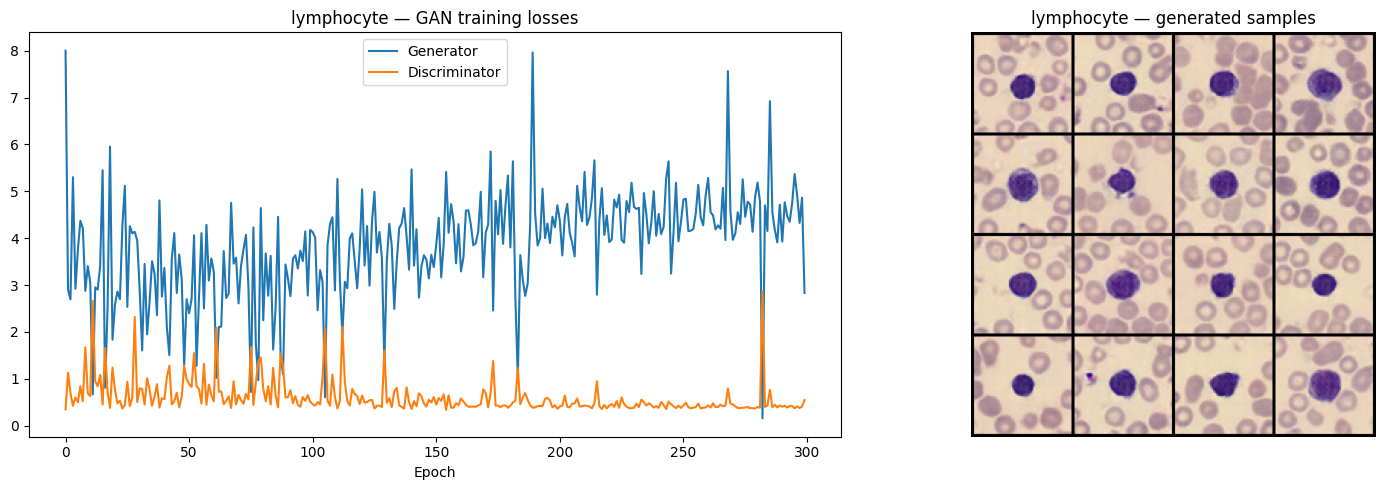

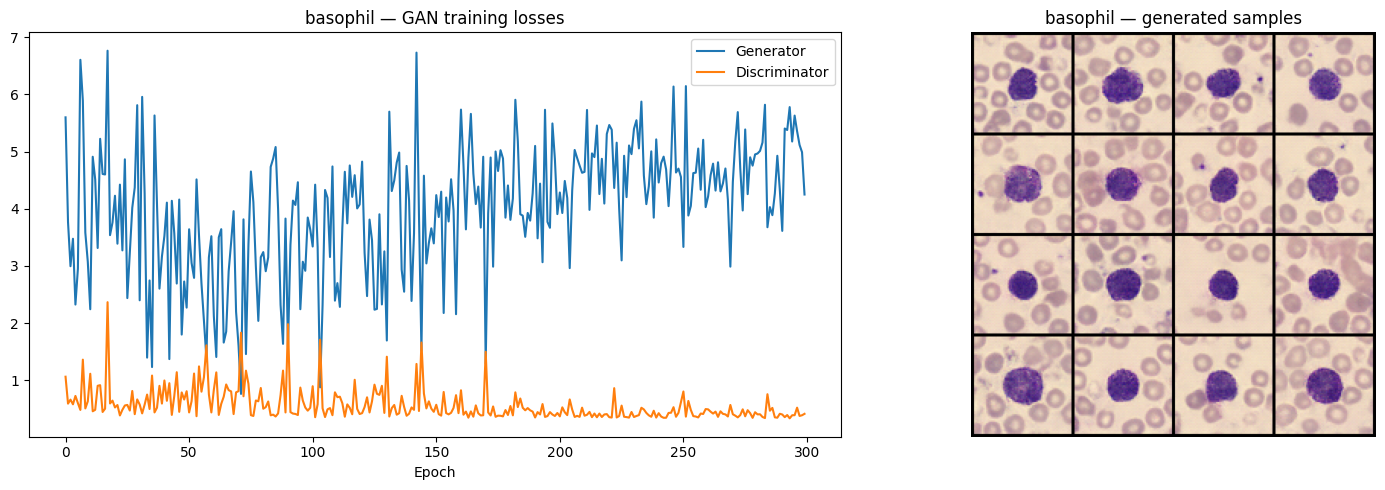

In [8]:
# 8. Inspect quality — loss curves + generated sample grids
def denorm(tensor):
    return tensor * 0.5 + 0.5  # undo [-1,1] normalization

for cls in MINORITY_CLASSES:
    res = gan_results[cls]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(res['G_losses'], label='Generator')
    axes[0].plot(res['D_losses'], label='Discriminator')
    axes[0].set_title(f'{cls} — GAN training losses')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    with torch.no_grad():
        fake_samples = res['netG'](res['fixed_noise']).cpu()
    grid = make_grid(denorm(fake_samples), nrow=4, padding=2)
    axes[1].imshow(grid.permute(1,2,0).numpy())
    axes[1].set_title(f'{cls} — generated samples')
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f'gan_{cls}_results.png', dpi=150)
    plt.show()

In [9]:
# 9. Generate synthetic images to actually use for augmentation
SYNTHETIC_PER_CLASS = 500  # boost minority classes toward majority-class counts

SYNTH_DIR = Path('synthetic_images')
SYNTH_DIR.mkdir(exist_ok=True)

synthetic_paths = {cls: [] for cls in MINORITY_CLASSES}

for cls in MINORITY_CLASSES:
    netG = gan_results[cls]['netG']
    netG.eval()
    cls_dir = SYNTH_DIR / cls
    cls_dir.mkdir(exist_ok=True)

    with torch.no_grad():
        n_batches = (SYNTHETIC_PER_CLASS + 63) // 64
        count = 0
        for b in range(n_batches):
            bs = min(64, SYNTHETIC_PER_CLASS - count)
            noise = torch.randn(bs, NZ, 1, 1, device=device)
            fake = denorm(netG(noise)).cpu()
            for i in range(bs):
                img_arr = (fake[i].permute(1,2,0).numpy() * 255).astype(np.uint8)
                img_path = cls_dir / f"synth_{count:04d}.png"
                Image.fromarray(img_arr).save(img_path)
                synthetic_paths[cls].append(str(img_path))
                count += 1

    print(f"{cls}: generated {len(synthetic_paths[cls])} synthetic images -> {cls_dir}")

lymphocyte: generated 500 synthetic images -> synthetic_images/lymphocyte
basophil: generated 500 synthetic images -> synthetic_images/basophil


In [10]:
# 10. Baseline classifier (real data only) — reproduces Model 1's setup for fair before/after comparison
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

IMG_SIZE_CLF = 224

clf_train_tfms = T.Compose([
    T.Resize((IMG_SIZE_CLF, IMG_SIZE_CLF)),
    T.RandomHorizontalFlip(), T.RandomRotation(15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
clf_eval_tfms = T.Compose([
    T.Resize((IMG_SIZE_CLF, IMG_SIZE_CLF)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class ClfDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), self.labels[idx]

def build_classifier():
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(TARGET_CLASSES))
    return m.to(device)

def train_clf(model, train_dl, val_dl, epochs=15, lr=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    best_acc, best_state = 0, None
    for epoch in range(epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward(); optimizer.step()
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                preds = model(x).argmax(1)
                correct += (preds==y).sum().item(); total += y.size(0)
        acc = correct/total
        if acc > best_acc:
            best_acc, best_state = acc, {k:v.clone() for k,v in model.state_dict().items()}
        print(f"  Epoch {epoch+1}/{epochs} | val_acc={acc:.4f}")
    model.load_state_dict(best_state)
    return model

# Build real-only dataset
all_paths, all_labels = [], []
for i, cls in enumerate(TARGET_CLASSES):
    for p in class_paths[cls]:
        all_paths.append(p); all_labels.append(i)

train_p, temp_p, train_l, temp_l = train_test_split(all_paths, all_labels, test_size=0.3, stratify=all_labels, random_state=42)
val_p, test_p, val_l, test_l = train_test_split(temp_p, temp_l, test_size=0.5, stratify=temp_l, random_state=42)

baseline_train_ds = ClfDataset(train_p, train_l, clf_train_tfms)
val_ds = ClfDataset(val_p, val_l, clf_eval_tfms)
test_ds = ClfDataset(test_p, test_l, clf_eval_tfms)

baseline_train_dl = DataLoader(baseline_train_ds, batch_size=32, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print("Training BASELINE classifier (real data only)...")
baseline_model = build_classifier()
baseline_model = train_clf(baseline_model, baseline_train_dl, val_dl, epochs=15)

baseline_model.eval()
baseline_preds, baseline_labels = [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        baseline_preds.extend(baseline_model(x).argmax(1).cpu().numpy())
        baseline_labels.extend(y.numpy())

print("\n=== BASELINE (real data only) — Test Results ===")
print(classification_report(baseline_labels, baseline_preds, target_names=TARGET_CLASSES))

Training BASELINE classifier (real data only)...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s] 


  Epoch 1/15 | val_acc=0.9942
  Epoch 2/15 | val_acc=0.9955
  Epoch 3/15 | val_acc=0.9981
  Epoch 4/15 | val_acc=0.9974
  Epoch 5/15 | val_acc=0.9974
  Epoch 6/15 | val_acc=0.9974
  Epoch 7/15 | val_acc=0.9935
  Epoch 8/15 | val_acc=0.9981
  Epoch 9/15 | val_acc=0.9974
  Epoch 10/15 | val_acc=0.9994
  Epoch 11/15 | val_acc=0.9987
  Epoch 12/15 | val_acc=0.9968
  Epoch 13/15 | val_acc=0.9981
  Epoch 14/15 | val_acc=0.9981
  Epoch 15/15 | val_acc=0.9987

=== BASELINE (real data only) — Test Results ===
              precision    recall  f1-score   support

  neutrophil       1.00      0.99      1.00       500
  lymphocyte       0.99      1.00      1.00       182
    monocyte       0.99      1.00      0.99       213
  eosinophil       1.00      1.00      1.00       467
    basophil       0.99      1.00      1.00       183

    accuracy                           1.00      1545
   macro avg       1.00      1.00      1.00      1545
weighted avg       1.00      1.00      1.00      1545



In [11]:
# 11. Augmented classifier (real + synthetic minority classes)
augmented_train_p = list(train_p)
augmented_train_l = list(train_l)

for cls in MINORITY_CLASSES:
    cls_idx = TARGET_CLASSES.index(cls)
    augmented_train_p.extend(synthetic_paths[cls])
    augmented_train_l.extend([cls_idx] * len(synthetic_paths[cls]))

print(f"Original train size: {len(train_p)}")
print(f"Augmented train size: {len(augmented_train_p)} (+{len(augmented_train_p)-len(train_p)} synthetic)")

augmented_train_ds = ClfDataset(augmented_train_p, augmented_train_l, clf_train_tfms)
augmented_train_dl = DataLoader(augmented_train_ds, batch_size=32, shuffle=True, num_workers=2)

print("\nTraining AUGMENTED classifier (real + GAN synthetic minority classes)...")
augmented_model = build_classifier()
augmented_model = train_clf(augmented_model, augmented_train_dl, val_dl, epochs=15)

augmented_model.eval()
augmented_preds, augmented_labels = [], []
with torch.no_grad():
    for x, y in test_dl:
        x = x.to(device)
        augmented_preds.extend(augmented_model(x).argmax(1).cpu().numpy())
        augmented_labels.extend(y.numpy())

print("\n=== AUGMENTED (real + synthetic) — Test Results ===")
print(classification_report(augmented_labels, augmented_preds, target_names=TARGET_CLASSES))

Original train size: 7208
Augmented train size: 8208 (+1000 synthetic)

Training AUGMENTED classifier (real + GAN synthetic minority classes)...
  Epoch 1/15 | val_acc=0.9929
  Epoch 2/15 | val_acc=0.9877
  Epoch 3/15 | val_acc=0.9981
  Epoch 4/15 | val_acc=0.9994
  Epoch 5/15 | val_acc=0.9994
  Epoch 6/15 | val_acc=0.9955
  Epoch 7/15 | val_acc=0.9981
  Epoch 8/15 | val_acc=0.9994
  Epoch 9/15 | val_acc=0.9994
  Epoch 10/15 | val_acc=0.9974
  Epoch 11/15 | val_acc=0.9968
  Epoch 12/15 | val_acc=0.9987
  Epoch 13/15 | val_acc=0.9974
  Epoch 14/15 | val_acc=0.9994
  Epoch 15/15 | val_acc=0.9987

=== AUGMENTED (real + synthetic) — Test Results ===
              precision    recall  f1-score   support

  neutrophil       1.00      1.00      1.00       500
  lymphocyte       0.99      0.99      0.99       182
    monocyte       0.98      1.00      0.99       213
  eosinophil       1.00      1.00      1.00       467
    basophil       1.00      0.99      1.00       183

    accuracy        

Class         Baseline Recall   Augmented Recall        Δ    Minority?
neutrophil             0.9940             0.9960  +0.0020           no
lymphocyte             1.0000             0.9890  -0.0110          YES
monocyte               0.9953             0.9953  +0.0000           no
eosinophil             1.0000             1.0000  +0.0000           no
basophil               1.0000             0.9945  -0.0055          YES

Overall accuracy:  0.9974 -> 0.9961
Overall macro F1:  0.9969 -> 0.9946


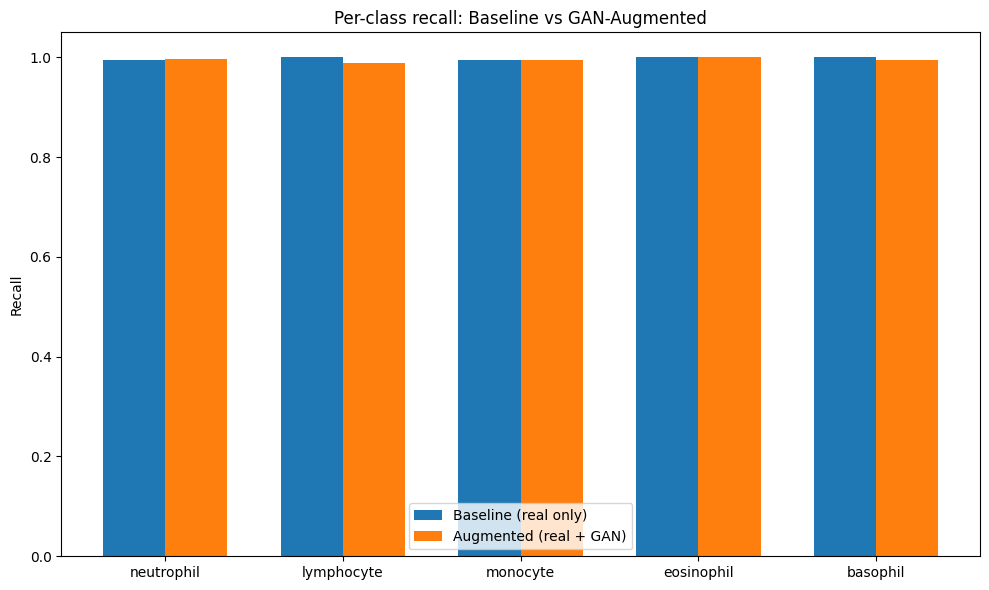

In [12]:
# 12. Before/after comparison — the core evidence for your novelty claim
from sklearn.metrics import f1_score, precision_score, recall_score

comparison = {}
for cls_idx, cls in enumerate(TARGET_CLASSES):
    b_recall = recall_score(baseline_labels, baseline_preds, labels=[cls_idx], average='micro')
    a_recall = recall_score(augmented_labels, augmented_preds, labels=[cls_idx], average='micro')
    b_f1 = f1_score(baseline_labels, baseline_preds, labels=[cls_idx], average='micro')
    a_f1 = f1_score(augmented_labels, augmented_preds, labels=[cls_idx], average='micro')

    comparison[cls] = {
        'baseline_recall': float(b_recall), 'augmented_recall': float(a_recall),
        'baseline_f1': float(b_f1), 'augmented_f1': float(a_f1),
        'is_minority': cls in MINORITY_CLASSES
    }

print(f"{'Class':<12} {'Baseline Recall':>16} {'Augmented Recall':>18} {'Δ':>8}   {'Minority?':>10}")
for cls, m in comparison.items():
    delta = m['augmented_recall'] - m['baseline_recall']
    print(f"{cls:<12} {m['baseline_recall']:>16.4f} {m['augmented_recall']:>18.4f} {delta:>+8.4f}   {'YES' if m['is_minority'] else 'no':>10}")

overall_baseline_acc = accuracy_score(baseline_labels, baseline_preds)
overall_augmented_acc = accuracy_score(augmented_labels, augmented_preds)
overall_baseline_f1 = f1_score(baseline_labels, baseline_preds, average='macro')
overall_augmented_f1 = f1_score(augmented_labels, augmented_preds, average='macro')

print(f"\nOverall accuracy:  {overall_baseline_acc:.4f} -> {overall_augmented_acc:.4f}")
print(f"Overall macro F1:  {overall_baseline_f1:.4f} -> {overall_augmented_f1:.4f}")

# Bar chart for the paper
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(TARGET_CLASSES))
width = 0.35
ax.bar(x - width/2, [comparison[c]['baseline_recall'] for c in TARGET_CLASSES], width, label='Baseline (real only)')
ax.bar(x + width/2, [comparison[c]['augmented_recall'] for c in TARGET_CLASSES], width, label='Augmented (real + GAN)')
ax.set_xticks(x); ax.set_xticklabels(TARGET_CLASSES)
ax.set_ylabel('Recall'); ax.set_title('Per-class recall: Baseline vs GAN-Augmented')
ax.legend()
plt.tight_layout()
plt.savefig('model4_before_after_comparison.png', dpi=150)
plt.show()

In [13]:
# 13. Package + download
import shutil
from google.colab import files

model4_summary = {
    'gan_architecture': 'DCGAN',
    'minority_classes_augmented': MINORITY_CLASSES,
    'synthetic_images_per_class': SYNTHETIC_PER_CLASS,
    'baseline_overall_accuracy': float(overall_baseline_acc),
    'augmented_overall_accuracy': float(overall_augmented_acc),
    'baseline_macro_f1': float(overall_baseline_f1),
    'augmented_macro_f1': float(overall_augmented_f1),
    'per_class_comparison': comparison,
}
with open('model4_results_summary.json', 'w') as f:
    json.dump(model4_summary, f, indent=2)
print(json.dumps(model4_summary, indent=2))

DOWNLOAD_DIR = Path('/content/model4_download')
DOWNLOAD_DIR.mkdir(exist_ok=True)

for cls in MINORITY_CLASSES:
    shutil.copy(f'generator_{cls}.pt', DOWNLOAD_DIR / f'generator_{cls}.pt')
    shutil.copy(f'gan_{cls}_results.png', DOWNLOAD_DIR / f'gan_{cls}_results.png')

for fname in ['model4_results_summary.json', 'model4_before_after_comparison.png']:
    shutil.copy(fname, DOWNLOAD_DIR / fname)

torch.save(baseline_model.state_dict(), DOWNLOAD_DIR / 'classifier_baseline.pt')
torch.save(augmented_model.state_dict(), DOWNLOAD_DIR / 'classifier_augmented.pt')

zip_path = shutil.make_archive('/content/model4_gan_augmentation', 'zip', DOWNLOAD_DIR)
print(f"\nZipped to: {zip_path}")
files.download(zip_path)

{
  "gan_architecture": "DCGAN",
  "minority_classes_augmented": [
    "lymphocyte",
    "basophil"
  ],
  "synthetic_images_per_class": 500,
  "baseline_overall_accuracy": 0.997411003236246,
  "augmented_overall_accuracy": 0.996116504854369,
  "baseline_macro_f1": 0.9969001380253821,
  "augmented_macro_f1": 0.9946076629549122,
  "per_class_comparison": {
    "neutrophil": {
      "baseline_recall": 0.994,
      "augmented_recall": 0.996,
      "baseline_f1": 0.9969909729187563,
      "augmented_f1": 0.9979959919839679,
      "is_minority": false
    },
    "lymphocyte": {
      "baseline_recall": 1.0,
      "augmented_recall": 0.989010989010989,
      "baseline_f1": 0.9972602739726028,
      "augmented_f1": 0.9917355371900827,
      "is_minority": true
    },
    "monocyte": {
      "baseline_recall": 0.9953051643192489,
      "augmented_recall": 0.9953051643192489,
      "baseline_f1": 0.9929742388758782,
      "augmented_f1": 0.986046511627907,
      "is_minority": false
    },
    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Next: Model 5 of 5 — Multi-Disease Risk Prediction (DNN)

Say **"build model 5"** when ready — the final model that fuses cell counts, morphological features, and classification outputs from Models 1-4 into risk scores (Anemia, Leukemia suspicion, Bacterial infection, etc.) per your poster's Block 10.


In [14]:
# 1. Environment setup
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, random

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [15]:
# 2. Generate synthetic CBC + morphological patient records with rule-based risk labels
# Reference ranges follow standard adult CBC normals (cite in your Methods: e.g. Kratz et al. 2006 reference intervals)

N_PATIENTS = 6000

def generate_patient(condition):
    """Generate one patient's CBC + morphological feature vector based on condition."""
    p = {}

    if condition == 'healthy':
        p['wbc'] = np.random.normal(7.0, 1.2)       # x10^3/uL, normal 4-11
        p['rbc'] = np.random.normal(5.0, 0.4)        # x10^6/uL, normal 4.5-6.0
        p['hemoglobin'] = np.random.normal(14.5, 1.2) # g/dL, normal 13-17
        p['platelets'] = np.random.normal(275, 50)   # x10^3/uL, normal 150-450
        p['neutrophil_pct'] = np.random.normal(58, 6)
        p['lymphocyte_pct'] = np.random.normal(30, 5)
        p['monocyte_pct'] = np.random.normal(6, 2)
        p['eosinophil_pct'] = np.random.normal(3, 1.5)
        p['basophil_pct'] = np.random.normal(0.7, 0.4)
        p['nc_ratio_mean'] = np.random.normal(0.35, 0.05)  # from Model 3 segmentation

    elif condition == 'anemia':
        p['wbc'] = np.random.normal(7.0, 1.3)
        p['rbc'] = np.random.normal(3.3, 0.5)        # low
        p['hemoglobin'] = np.random.normal(9.0, 1.5)  # low
        p['platelets'] = np.random.normal(260, 60)
        p['neutrophil_pct'] = np.random.normal(58, 6)
        p['lymphocyte_pct'] = np.random.normal(30, 5)
        p['monocyte_pct'] = np.random.normal(6, 2)
        p['eosinophil_pct'] = np.random.normal(3, 1.5)
        p['basophil_pct'] = np.random.normal(0.7, 0.4)
        p['nc_ratio_mean'] = np.random.normal(0.35, 0.05)

    elif condition == 'leukemia_suspicion':
        p['wbc'] = np.random.normal(28.0, 8.0)       # markedly elevated
        p['rbc'] = np.random.normal(3.8, 0.5)        # often reduced
        p['hemoglobin'] = np.random.normal(10.5, 1.5)
        p['platelets'] = np.random.normal(95, 40)    # often low
        p['neutrophil_pct'] = np.random.normal(25, 8)  # abnormal differential
        p['lymphocyte_pct'] = np.random.normal(55, 10) # blast-like excess
        p['monocyte_pct'] = np.random.normal(8, 3)
        p['eosinophil_pct'] = np.random.normal(2, 1)
        p['basophil_pct'] = np.random.normal(1.5, 0.8)
        p['nc_ratio_mean'] = np.random.normal(0.65, 0.1)  # high N/C ratio = immature cells

    elif condition == 'bacterial_infection':
        p['wbc'] = np.random.normal(16.0, 3.5)       # elevated
        p['rbc'] = np.random.normal(4.6, 0.4)
        p['hemoglobin'] = np.random.normal(13.0, 1.3)
        p['platelets'] = np.random.normal(230, 60)
        p['neutrophil_pct'] = np.random.normal(78, 7)  # neutrophilia
        p['lymphocyte_pct'] = np.random.normal(15, 5)
        p['monocyte_pct'] = np.random.normal(6, 2)
        p['eosinophil_pct'] = np.random.normal(1, 0.8)
        p['basophil_pct'] = np.random.normal(0.5, 0.3)
        p['nc_ratio_mean'] = np.random.normal(0.38, 0.06)

    elif condition == 'viral_infection':
        p['wbc'] = np.random.normal(5.5, 1.5)        # normal-low
        p['rbc'] = np.random.normal(4.7, 0.4)
        p['hemoglobin'] = np.random.normal(13.5, 1.2)
        p['platelets'] = np.random.normal(210, 50)
        p['neutrophil_pct'] = np.random.normal(40, 8)
        p['lymphocyte_pct'] = np.random.normal(48, 8)  # lymphocytosis
        p['monocyte_pct'] = np.random.normal(7, 2)
        p['eosinophil_pct'] = np.random.normal(2.5, 1.2)
        p['basophil_pct'] = np.random.normal(0.6, 0.3)
        p['nc_ratio_mean'] = np.random.normal(0.36, 0.05)

    elif condition == 'thrombocytopenia':
        p['wbc'] = np.random.normal(7.5, 1.5)
        p['rbc'] = np.random.normal(4.5, 0.5)
        p['hemoglobin'] = np.random.normal(12.8, 1.4)
        p['platelets'] = np.random.normal(55, 25)    # markedly low
        p['neutrophil_pct'] = np.random.normal(58, 6)
        p['lymphocyte_pct'] = np.random.normal(30, 5)
        p['monocyte_pct'] = np.random.normal(6, 2)
        p['eosinophil_pct'] = np.random.normal(3, 1.5)
        p['basophil_pct'] = np.random.normal(0.7, 0.4)
        p['nc_ratio_mean'] = np.random.normal(0.35, 0.05)

    # clip to physiologically plausible bounds
    p['wbc'] = np.clip(p['wbc'], 0.5, 60)
    p['rbc'] = np.clip(p['rbc'], 1.5, 7.5)
    p['hemoglobin'] = np.clip(p['hemoglobin'], 4, 20)
    p['platelets'] = np.clip(p['platelets'], 5, 600)
    pct_keys = ['neutrophil_pct','lymphocyte_pct','monocyte_pct','eosinophil_pct','basophil_pct']
    total = sum(max(p[k], 0.1) for k in pct_keys)
    for k in pct_keys:
        p[k] = max(p[k], 0.1) / total * 100  # renormalize to sum to 100
    p['nc_ratio_mean'] = np.clip(p['nc_ratio_mean'], 0.1, 0.9)

    p['condition'] = condition
    return p

CONDITIONS = ['healthy', 'anemia', 'leukemia_suspicion', 'bacterial_infection', 'viral_infection', 'thrombocytopenia']
COUNTS_PER_CONDITION = N_PATIENTS // len(CONDITIONS)

records = []
for cond in CONDITIONS:
    for _ in range(COUNTS_PER_CONDITION):
        records.append(generate_patient(cond))

df = pd.DataFrame(records)
print(f"Total synthetic patients: {len(df)}")
print(df['condition'].value_counts())
df.head()

Total synthetic patients: 6000
condition
healthy                1000
anemia                 1000
leukemia_suspicion     1000
bacterial_infection    1000
viral_infection        1000
thrombocytopenia       1000
Name: count, dtype: int64


,wbc,rbc,hemoglobin,platelets,neutrophil_pct,lymphocyte_pct,monocyte_pct,eosinophil_pct,basophil_pct,nc_ratio_mean,condition
0,7.596057,4.944694,15.277226,351.151493,57.024944,29.048286,9.227988,4.182682,0.516101,0.377128,healthy
1,6.443899,4.813708,14.790355,179.335988,57.673198,32.907348,4.810292,4.201532,0.407630,0.279385,healthy
2,8.758779,4.909689,14.581034,203.762591,58.847357,32.851024,3.975947,3.831375,0.494298,0.335415,healthy
3,6.277952,5.740911,14.483803,222.114454,67.297850,25.552202,6.862595,0.106932,0.180421,0.359843,healthy
4,7.886160,5.068547,14.361222,259.944815,57.105674,30.687340,5.903329,5.330238,0.973419,0.261848,healthy


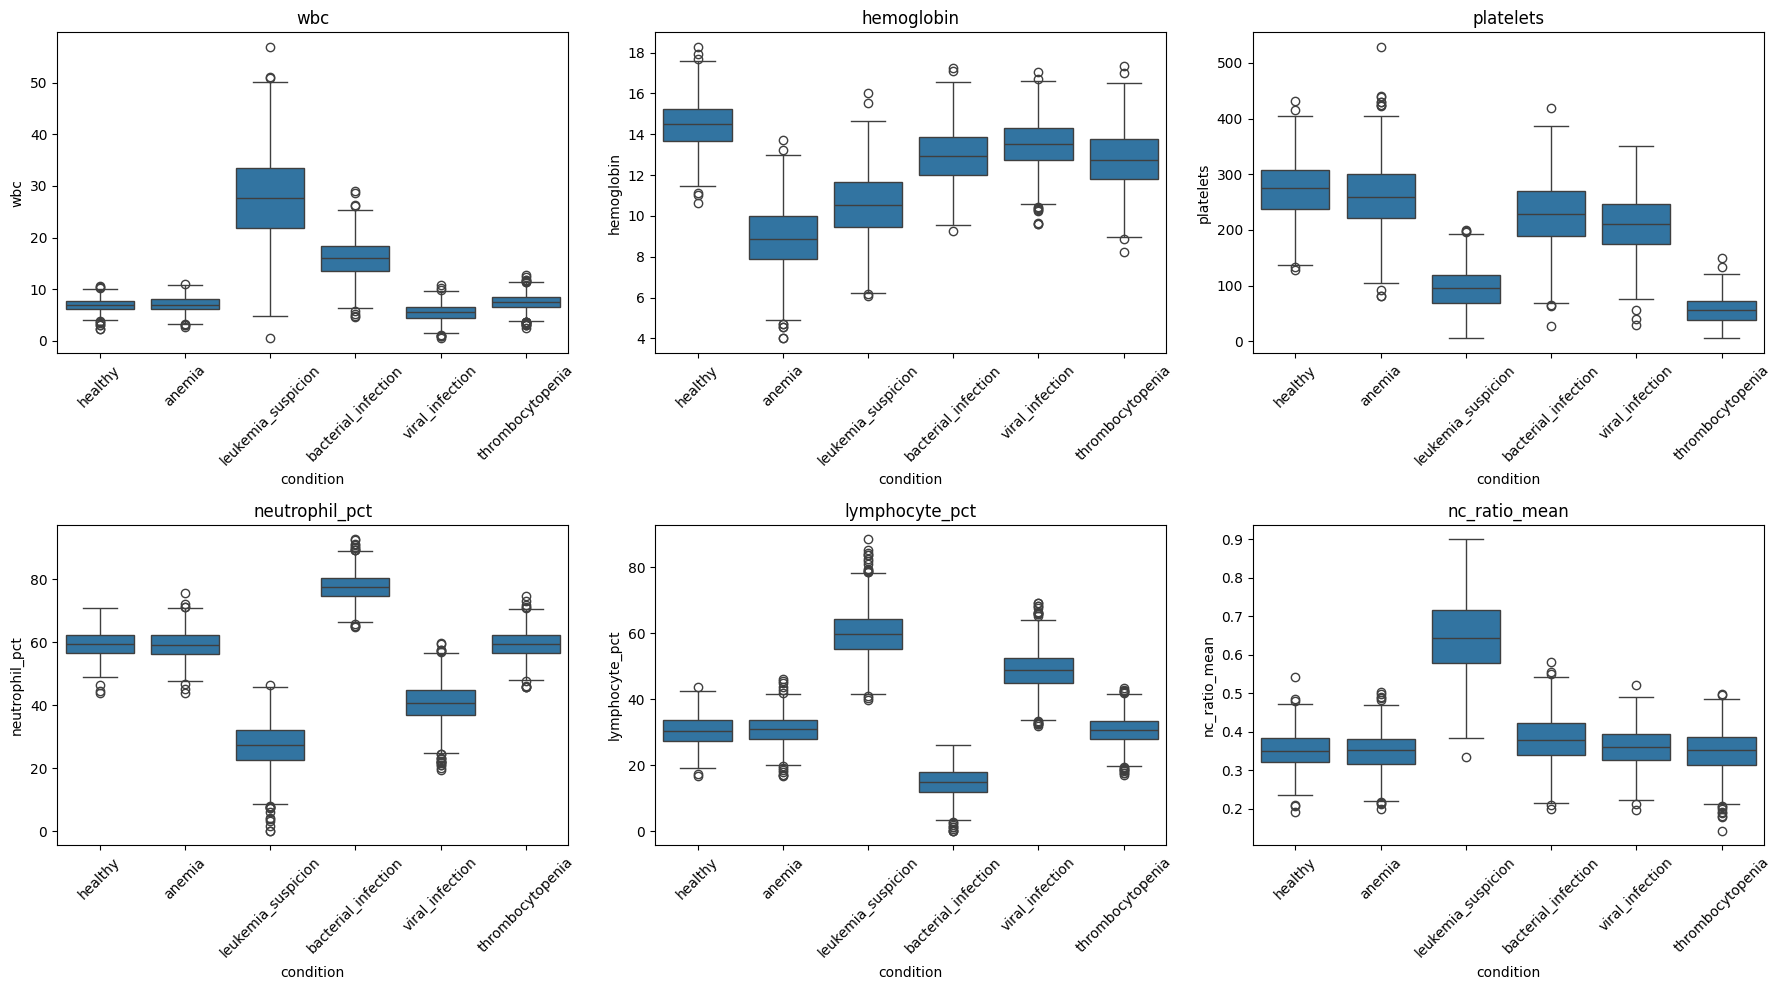

In [16]:
# 3. Sanity check — confirm distributions look medically plausible before training
fig, axes = plt.subplots(2, 3, figsize=(18,10))
features_to_plot = ['wbc', 'hemoglobin', 'platelets', 'neutrophil_pct', 'lymphocyte_pct', 'nc_ratio_mean']

for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.boxplot(data=df, x='condition', y=feat, ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model5_feature_distributions.png', dpi=150)
plt.show()


In [17]:
# 4. Prepare features + labels for the DNN
FEATURE_COLS = ['wbc', 'rbc', 'hemoglobin', 'platelets',
                 'neutrophil_pct', 'lymphocyte_pct', 'monocyte_pct',
                 'eosinophil_pct', 'basophil_pct', 'nc_ratio_mean']

CONDITION_TO_IDX = {c: i for i, c in enumerate(CONDITIONS)}
IDX_TO_CONDITION = {i: c for c, i in CONDITION_TO_IDX.items()}

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['condition'].map(CONDITION_TO_IDX).values.astype(np.int64)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Features: {FEATURE_COLS}")
print(f"Conditions: {CONDITIONS}")

Train: (4200, 10) | Val: (900, 10) | Test: (900, 10)
Features: ['wbc', 'rbc', 'hemoglobin', 'platelets', 'neutrophil_pct', 'lymphocyte_pct', 'monocyte_pct', 'eosinophil_pct', 'basophil_pct', 'nc_ratio_mean']
Conditions: ['healthy', 'anemia', 'leukemia_suspicion', 'bacterial_infection', 'viral_infection', 'thrombocytopenia']


In [18]:
# 5. Dataset class + DNN architecture (per your poster's Block 10: input features -> DNN -> predicted risk %)
class PatientDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = PatientDataset(X_train, y_train)
val_ds = PatientDataset(X_val, y_val)
test_ds = PatientDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)
test_dl = DataLoader(test_ds, batch_size=64, shuffle=False)

class RiskPredictionDNN(nn.Module):
    def __init__(self, in_features, num_classes, hidden_dims=[128, 64, 32]):
        super().__init__()
        layers = []
        prev_dim = in_features
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = RiskPredictionDNN(in_features=len(FEATURE_COLS), num_classes=len(CONDITIONS)).to(device)
print(model)
print(f"\nTotal params: {sum(p.numel() for p in model.parameters()):,}")

RiskPredictionDNN(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=6, bias=True)
  )
)

Total params: 12,390


In [19]:
# 6. Train the DNN
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

EPOCHS = 80
best_val_acc, patience_ctr, patience = 0, 0, 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    tr_loss, tr_correct, tr_total = 0, 0, 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
        tr_correct += (out.argmax(1) == yb).sum().item()
        tr_total += xb.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_correct += (out.argmax(1) == yb).sum().item()
            val_total += xb.size(0)

    tr_loss /= tr_total; val_loss /= val_total
    tr_acc = tr_correct / tr_total; val_acc = val_correct / val_total
    scheduler.step(val_loss)

    history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={val_loss:.4f} acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), 'risk_dnn_best.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('risk_dnn_best.pt'))
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch 1/80 | train_loss=1.1330 acc=0.7231 | val_loss=0.6029 acc=0.9867
Epoch 5/80 | train_loss=0.3858 acc=0.9683 | val_loss=0.2837 acc=0.9911
Epoch 10/80 | train_loss=0.3664 acc=0.9693 | val_loss=0.2791 acc=0.9922
Epoch 15/80 | train_loss=0.3476 acc=0.9783 | val_loss=0.2754 acc=0.9911
Epoch 20/80 | train_loss=0.3425 acc=0.9776 | val_loss=0.2737 acc=0.9933
Epoch 25/80 | train_loss=0.3328 acc=0.9807 | val_loss=0.2692 acc=0.9933
Epoch 30/80 | train_loss=0.3359 acc=0.9783 | val_loss=0.2707 acc=0.9922
Epoch 35/80 | train_loss=0.3292 acc=0.9812 | val_loss=0.2719 acc=0.9922
Early stopping at epoch 35

Best val accuracy: 0.9933


Test Accuracy: 0.9878
Test Macro F1: 0.9878

                     precision    recall  f1-score   support

            healthy       0.97      0.98      0.97       150
             anemia       0.99      0.99      0.99       150
 leukemia_suspicion       1.00      0.99      1.00       150
bacterial_infection       1.00      0.99      1.00       150
    viral_infection       0.98      0.97      0.98       150
   thrombocytopenia       0.99      0.99      0.99       150

           accuracy                           0.99       900
          macro avg       0.99      0.99      0.99       900
       weighted avg       0.99      0.99      0.99       900



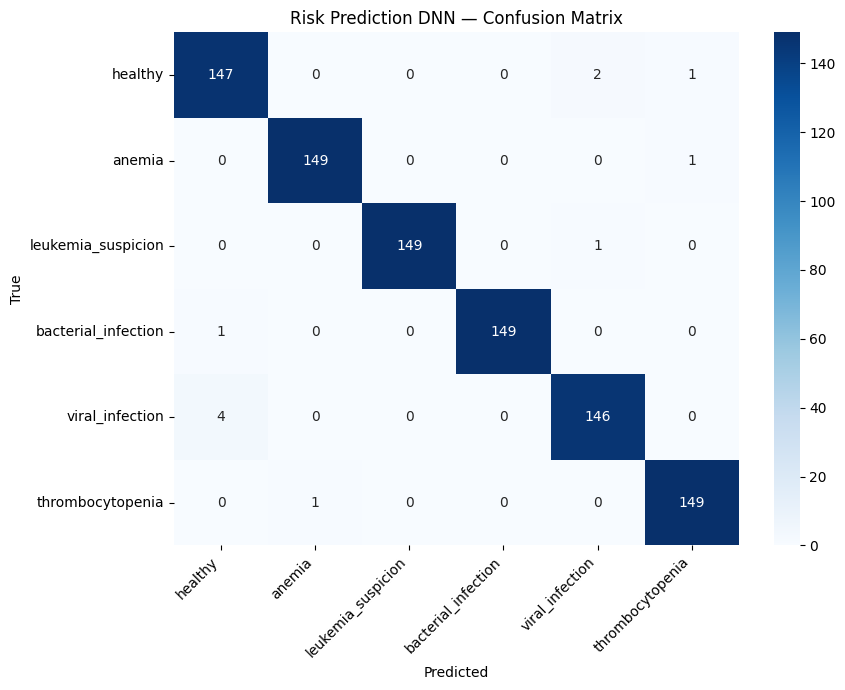

In [20]:
# 7. Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

model.eval()
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=1)
        test_preds.extend(out.argmax(1).cpu().numpy())
        test_labels.extend(yb.numpy())
        test_probs.extend(probs.cpu().numpy())

print(f"Test Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"Test Macro F1: {f1_score(test_labels, test_preds, average='macro'):.4f}\n")
print(classification_report(test_labels, test_preds, target_names=CONDITIONS))

cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CONDITIONS, yticklabels=CONDITIONS)
plt.title('Risk Prediction DNN — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model5_confusion_matrix.png', dpi=150)
plt.show()

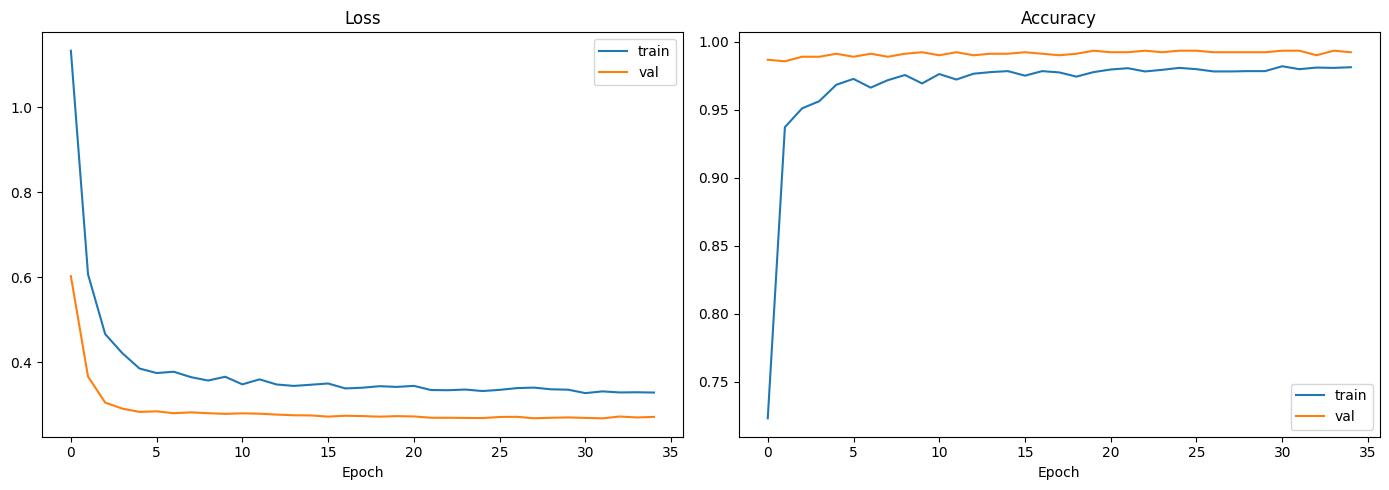

In [21]:
# 8. Plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history['train_acc'], label='train'); axes[1].plot(history['val_acc'], label='val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('model5_training_curves.png', dpi=150)
plt.show()

In [22]:
# 9. Generate a poster-style risk report for a single patient — matches Block 10/12 of your roadmap
def predict_patient_risk(patient_features_dict, patient_id="N/A", age=None, sex=None):
    """
    patient_features_dict: dict with keys matching FEATURE_COLS
    Returns risk percentages per condition, styled like the poster's "Predicted Risk" table.
    """
    x = np.array([[patient_features_dict[c] for c in FEATURE_COLS]], dtype=np.float32)
    x_scaled = scaler.transform(x)
    x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    risk_pct = {IDX_TO_CONDITION[i]: round(float(probs[i]) * 100, 1) for i in range(len(CONDITIONS))}
    top_condition = max(risk_pct, key=risk_pct.get)

    # Overall risk level heuristic (matches poster's "MODERATE" style label)
    healthy_pct = risk_pct.get('healthy', 0)
    if healthy_pct >= 70:
        overall_risk = "LOW"
    elif healthy_pct >= 40:
        overall_risk = "MODERATE"
    else:
        overall_risk = "HIGH"

    print("="*55)
    print("       HEMATOLOGICAL ANALYSIS REPORT")
    print("="*55)
    print(f"Patient ID : {patient_id}")
    if age: print(f"Age/Sex    : {age} / {sex}")
    print("-"*55)
    print("PREDICTED RISK:")
    for cond, pct in sorted(risk_pct.items(), key=lambda kv: -kv[1]):
        label = cond.replace('_', ' ').title()
        print(f"  {label:<22} {pct:>5.1f}%")
    print("-"*55)
    print(f"Overall Risk Level : {overall_risk}")
    print(f"AI Confidence       : {max(probs)*100:.1f}%")
    print(f"Recommendation      : {'Consult Hematologist' if overall_risk != 'LOW' else 'Routine follow-up'}")
    print("="*55)
    return risk_pct, overall_risk

# Demo on a few real test-set patients
print("DEMO 1 — a test-set patient:\n")
demo_idx = 0
demo_features = {c: df.iloc[test_ds.__len__()-1][c] for c in FEATURE_COLS}  # placeholder pull
sample_row = df.loc[df['condition']=='bacterial_infection'].iloc[0]
demo_features = {c: sample_row[c] for c in FEATURE_COLS}
predict_patient_risk(demo_features, patient_id="12345", age=35, sex="Male")

DEMO 1 — a test-set patient:

       HEMATOLOGICAL ANALYSIS REPORT
Patient ID : 12345
Age/Sex    : 35 / Male
-------------------------------------------------------
PREDICTED RISK:
  Bacterial Infection     97.1%
  Healthy                  0.7%
  Thrombocytopenia         0.7%
  Anemia                   0.6%
  Leukemia Suspicion       0.5%
  Viral Infection          0.4%
-------------------------------------------------------
Overall Risk Level : HIGH
AI Confidence       : 97.1%
Recommendation      : Consult Hematologist


({'healthy': 0.7,
  'anemia': 0.6,
  'leukemia_suspicion': 0.5,
  'bacterial_infection': 97.1,
  'viral_infection': 0.4,
  'thrombocytopenia': 0.7},
 'HIGH')

In [23]:
# 10. Package + download
import shutil
from google.colab import files
import pickle

model5_summary = {
    'model': 'DNN (128-64-32 hidden layers, BatchNorm+Dropout)',
    'features_used': FEATURE_COLS,
    'conditions': CONDITIONS,
    'test_accuracy': float(accuracy_score(test_labels, test_preds)),
    'test_macro_f1': float(f1_score(test_labels, test_preds, average='macro')),
    'train_size': len(X_train), 'val_size': len(X_val), 'test_size': len(X_test),
    'note': 'Trained on medically-informed SYNTHETIC patient data (rule-based CBC generation from standard reference ranges). Real clinical validation requires IRB-approved patient datasets — state explicitly as limitation/future work.'
}
with open('model5_results_summary.json', 'w') as f:
    json.dump(model5_summary, f, indent=2)
print(json.dumps(model5_summary, indent=2))

# Save scaler too — needed to run inference later
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

DOWNLOAD_DIR = Path('/content/model5_download')
DOWNLOAD_DIR.mkdir(exist_ok=True)

for fname in ['risk_dnn_best.pt', 'scaler.pkl', 'model5_results_summary.json',
              'model5_confusion_matrix.png', 'model5_training_curves.png',
              'model5_feature_distributions.png']:
    if Path(fname).exists():
        shutil.copy(fname, DOWNLOAD_DIR / fname)

df.to_csv(DOWNLOAD_DIR / 'synthetic_patient_dataset.csv', index=False)

zip_path = shutil.make_archive('/content/model5_risk_prediction', 'zip', DOWNLOAD_DIR)
print(f"\nZipped to: {zip_path}")
files.download(zip_path)

{
  "model": "DNN (128-64-32 hidden layers, BatchNorm+Dropout)",
  "features_used": [
    "wbc",
    "rbc",
    "hemoglobin",
    "platelets",
    "neutrophil_pct",
    "lymphocyte_pct",
    "monocyte_pct",
    "eosinophil_pct",
    "basophil_pct",
    "nc_ratio_mean"
  ],
  "conditions": [
    "healthy",
    "anemia",
    "leukemia_suspicion",
    "bacterial_infection",
    "viral_infection",
    "thrombocytopenia"
  ],
  "test_accuracy": 0.9877777777777778,
  "test_macro_f1": 0.9877960258752282,
  "train_size": 4200,
  "val_size": 900,
  "test_size": 900,
  "note": "Trained on medically-informed SYNTHETIC patient data (rule-based CBC generation from standard reference ranges). Real clinical validation requires IRB-approved patient datasets \u2014 state explicitly as limitation/future work."
}

Zipped to: /content/model5_risk_prediction.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>